## Download onto Google Colab

In [ ]:
import gdown

# Replace the ID with the actual file ID from Google Drive link
#file_id = "1cd2g_6jt7Ccnv8IVNQdFL_jmVn4lep-n"
file_id_grey = "1x8Kc4E15jwqtQ90OjMbBj2kSN_Q0Zsm7"
gdown.download(f"https://drive.google.com/uc?id={file_id_grey}", "moon.jpg", quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1x8Kc4E15jwqtQ90OjMbBj2kSN_Q0Zsm7
To: /content/moon.jpg
100%|██████████| 135k/135k [00:00<00:00, 35.5MB/s]


'moon.jpg'

#LAB 4


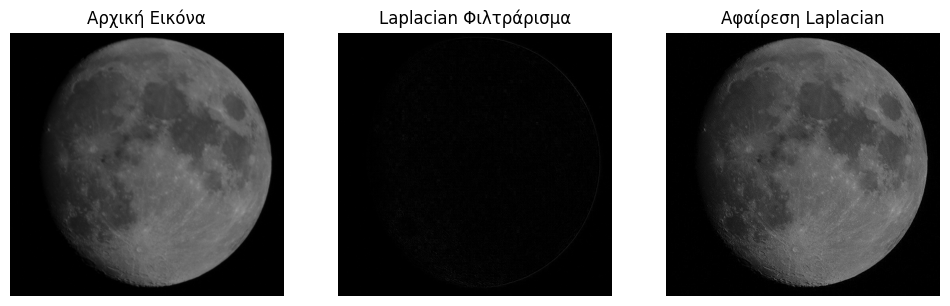

In [ ]:
# Cell 1: Εισαγωγή Βασικών Βιβλιοθηκών
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import generic_filter

# Για εμφάνιση εικόνων στο Colab
%matplotlib inline
# Cell 2: Άσκηση 1

# Ανάγνωση της εικόνας (χρώμα) και μετατροπή σε RGB για εμφάνιση με matplotlib
f = cv2.imread('moon.jpg', cv2.IMREAD_COLOR)
f_rgb = cv2.cvtColor(f, cv2.COLOR_BGR2RGB)
f2 = f_rgb.astype(np.float32) / 255.0

# Ορισμός του Laplacian φίλτρου με παράμετρο 0 (4-συνδεδεμένο Laplacian)
laplacian_kernel = np.array([[0, 1, 0],
                             [1, -4, 1],
                             [0, 1, 0]], dtype=np.float32)

# Εφαρμογή φίλτρου (χρήση replicate για τα όρια)
g = cv2.filter2D(f2, -1, laplacian_kernel, borderType=cv2.BORDER_REPLICATE)

# Εμφάνιση εικόνων
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(f_rgb)
plt.title('Αρχική Εικόνα')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(g, cmap='gray')
plt.title('Laplacian Φιλτράρισμα')
plt.axis('off')

plt.subplot(1,3,3)
g3 = f2 - g
plt.imshow(np.clip(g3, 0, 1))
plt.title('Αφαίρεση Laplacian')
plt.axis('off')

plt.show()


In [ ]:
import gdown

# Replace the ID with the actual file ID from Google Drive link
#file_id = "1cd2g_6jt7Ccnv8IVNQdFL_jmVn4lep-n"
file_id_grey = "10UXyMFm0X4KQxjM83x_Pc58rWfY2HAJV"
gdown.download(f"https://drive.google.com/uc?id={file_id_grey}", "circuit.tif", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=10UXyMFm0X4KQxjM83x_Pc58rWfY2HAJV
To: /content/circuit.tif
100%|██████████| 76.8k/76.8k [00:00<00:00, 53.2MB/s]


'circuit.tif'

Γεωμετρικός μέσος (circuit.tif)


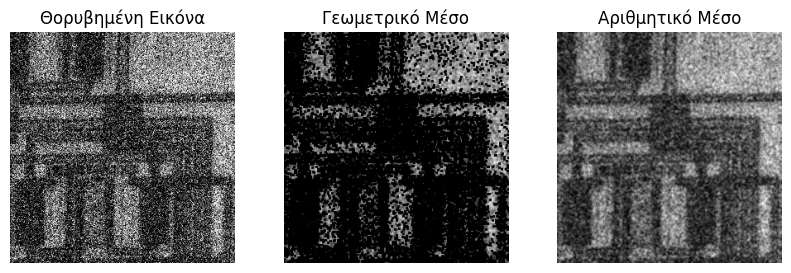

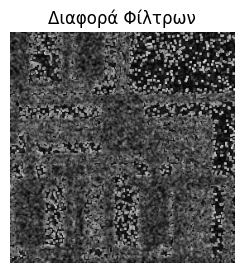

In [ ]:
# Cell 3: Άσκηση 2

# Ανάγνωση της εικόνας circuit.tif σε grayscale και κανονικοποίηση
a = cv2.imread('circuit.tif', cv2.IMREAD_GRAYSCALE)
a = a.astype(np.float32) / 255.0

# Προσθήκη Gaussian θορύβου (μέση τιμή 0, διακύμανση 0.1)
noise = np.random.normal(0, np.sqrt(0.1), a.shape)
b = a + noise
b = np.clip(b, 0, 1)

plt.figure(figsize=(10,3))
plt.subplot(1,3,1)
plt.imshow(b, cmap='gray')
plt.title('Θορυβημένη Εικόνα')
plt.axis('off')

# Συνάρτηση για υπολογισμό γεωμετρικού μέσου (με προσθήκη μικρού epsilon για αποφυγή λογαρίθμων του 0)
def geo_mean_filter(window):
    eps = 1e-10
    return np.exp(np.mean(np.log(window + eps)))

# Εφαρμογή φίλτρου γεωμετρικού μέσου με παράθυρο 3x3
g1 = generic_filter(b, geo_mean_filter, size=3)

plt.subplot(1,3,2)
plt.imshow(g1, cmap='gray')
plt.title('Γεωμετρικό Μέσο')
plt.axis('off')

# Εφαρμογή φίλτρου αritmιστικού μέσου (μέσος όρος με παράθυρο 3x3)
g2 = cv2.blur(b, (3,3))

plt.subplot(1,3,3)
plt.imshow(g2, cmap='gray')
plt.title('Αριθμητικό Μέσο')
plt.axis('off')

plt.show()

# Εμφάνιση της διαφοράς μεταξύ των δύο φίλτρων
diff = np.abs(g1 - g2)
plt.figure(figsize=(4,3))
plt.imshow(diff, cmap='gray')
plt.title('Διαφορά Φίλτρων')
plt.axis('off')
plt.show()

Ευρεση ακμών

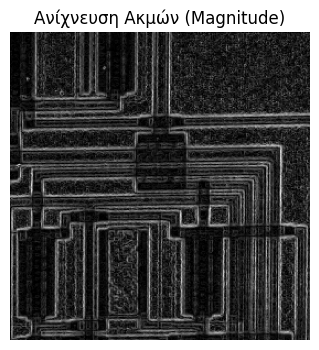

In [ ]:
# Cell 4: Άσκηση 3

# Ανάγνωση της αρχικής εικόνας circuit.tif (σε grayscale) και κανονικοποίηση
a_orig = cv2.imread('circuit.tif', cv2.IMREAD_GRAYSCALE)
a_orig = a_orig.astype(np.float32) / 255.0

# Ορισμός του φίλτρου για οριζόντια διαφορά: h = [-1, 1]
h = np.array([-1, 1], dtype=np.float32)

# Υπολογισμός οριζόντιου και κάθετου gradient με χρήση cv2.filter2D
fx = cv2.filter2D(a_orig, -1, h.reshape(1, -1), borderType=cv2.BORDER_REPLICATE)
fy = cv2.filter2D(a_orig, -1, h.reshape(-1, 1), borderType=cv2.BORDER_REPLICATE)

# Υπολογισμός του μέτρου του gradient και κλιμάκωση σε 0-255
m = np.sqrt(fx**2 + fy**2)
m = np.clip(m * 255, 0, 255).astype(np.uint8)

plt.figure(figsize=(5,4))
plt.imshow(m, cmap='gray')
plt.title('Ανίχνευση Ακμών (Magnitude)')
plt.axis('off')
plt.show()

Υπολογισμός Gradient για Έγχρωμη Εικόνα lena.bmp

Downloading...
From: https://drive.google.com/uc?id=1Ewguo7meX3rw3RDFb17jbAfWDT2JLIzl
To: /content/lena_color.jpg
100%|██████████| 786k/786k [00:00<00:00, 52.4MB/s]


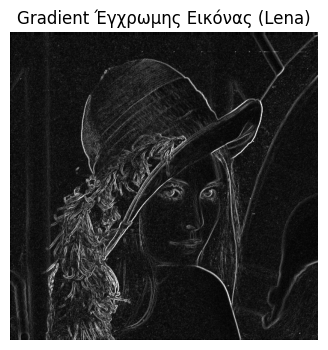

In [ ]:
import gdown

# Replace the ID with the actual file ID from Google Drive link
#file_id = "1cd2g_6jt7Ccnv8IVNQdFL_jmVn4lep-n"
file_id_grey = "1Ewguo7meX3rw3RDFb17jbAfWDT2JLIzl"
gdown.download(f"https://drive.google.com/uc?id={file_id_grey}", "lena_color.jpg", quiet=False)

# Ανάγνωση της έγχρωμης εικόνας lena.bmp και μετατροπή σε RGB
img = cv2.imread('lena_color.jpg', cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_float = img_rgb.astype(np.float32) / 255.0

# Ορισμός των φίλτρων για κάθε κανάλι
# Για οριζόντια παράγωγο: χρησιμοποιούμε το αντίστροφο του [-1, 1] (λόγω του conv)
kernel_fx = np.array([[1, -1]], dtype=np.float32)
# Για κάθετη παράγωγο: χρησιμοποιούμε το [-1; 1] όπως είναι
kernel_fy = np.array([[-1],
                      [ 1]], dtype=np.float32)

m_total = np.zeros(img_float.shape[:2], dtype=np.float32)
# Επεξεργασία καναλιών
for i in range(3):
    channel = img_float[:, :, i]
    fx = cv2.filter2D(channel, -1, kernel_fx, borderType=cv2.BORDER_REPLICATE)
    fy = cv2.filter2D(channel, -1, kernel_fy, borderType=cv2.BORDER_REPLICATE)
    magnitude = np.sqrt(fx**2 + fy**2)
    m_total += magnitude

# Κλιμάκωση του συνολικού gradient σε 0-255
m_total_scaled = np.clip(m_total * 255, 0, 255).astype(np.uint8)

plt.figure(figsize=(5,4))
plt.imshow(m_total_scaled, cmap='gray')
plt.title('Gradient Έγχρωμης Εικόνας (Lena)')
plt.axis('off')
plt.show()
